In [1]:
#libraires and other imports here

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import accuracy_score, mean_squared_error
import numpy as np

In [2]:
#reading the dataset
data = pd.read_csv('all_songs_data.csv')

#picking only data after 2002, and data from columns of interest
data = data[data['Year'] >= 2003]
data_cleaned = data[['Year', 'Song Title', 'Artist', 'Rank', 'Featured Artists']]

data_cleaned.head()

,Year,Song Title,Artist,Rank,Featured Artists
4400,2003.0,In Da Club,50 Cent,1,[]
4401,2003.0,Ignition,R. Kelly,2,[]
4402,2003.0,Get Busy,Sean Paul,3,[]
4403,2003.0,Crazy In Love,Beyonce feat. Jay-Z,4,"[{'api_path': '/artists/2', 'header_image_url'..."
4404,2003.0,When I'm Gone,3 Doors Down,5,[]


In [3]:
#cleaning up data for use in later calculations
#for count calculation purpose
#Featured Artists is valued in as 1 irrespective of the number of featuring artists be it 1 or more
data_cleaned['Featured Artists'] = data_cleaned['Artist'].apply(lambda x: 1 if 'feat.' in x.lower() or 'featuring' in x.lower() else 0)

#splitting featured artist names from Artist names 
data_cleaned['Artist'] = data_cleaned['Artist'].apply(lambda x: x.split(' feat.')[0].split(' featuring')[0].strip())

data_cleaned.head()

/tmp/ipykernel_148/2731811449.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_cleaned['Featured Artists'] = data_cleaned['Artist'].apply(lambda x: 1 if 'feat.' in x.lower() or 'featuring' in x.lower() else 0)
/tmp/ipykernel_148/2731811449.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_cleaned['Artist'] = data_cleaned['Artist'].apply(lambda x: x.split(' feat.')[0].split(' featuring')[0].strip())


,Year,Song Title,Artist,Rank,Featured Artists
4400,2003.0,In Da Club,50 Cent,1,0
4401,2003.0,Ignition,R. Kelly,2,0
4402,2003.0,Get Busy,Sean Paul,3,0
4403,2003.0,Crazy In Love,Beyonce,4,1
4404,2003.0,When I'm Gone,3 Doors Down,5,0


In [4]:
#caulating counts for dominant artist per year in terms of how many terms an artist is on the list per year
dominant_artist_per_year = data_cleaned.groupby(['Year', 'Artist']).size().reset_index(name='total_count')
dominant_artist_per_year = dominant_artist_per_year.loc[dominant_artist_per_year.groupby('Year')['total_count'].idxmax()].reset_index(drop=True)
dominant_songs = pd.merge(dominant_artist_per_year[['Year', 'Artist']], data_cleaned, on=['Year', 'Artist'])
artist_song_count = dominant_songs.groupby(['Year', 'Artist', 'Featured Artists']).size().reset_index(name='count')

#creating a table with the summary of the calcutations
dominant_artist_summary = artist_song_count.pivot_table(values='count', index=['Year', 'Artist'], columns='Featured Artists', fill_value=0)
dominant_artist_summary.columns = ['without_feature', 'with_feature']
dominant_artist_summary['total_count'] = dominant_artist_summary['without_feature'] + dominant_artist_summary['with_feature']
dominant_artist_summary = dominant_artist_summary.reset_index()

dominant_artist_summary

,Year,Artist,without_feature,with_feature,total_count
0,2003.0,50 Cent,3.0,1.0,4.0
1,2004.0,Alicia Keys,2.0,1.0,3.0
2,2005.0,50 Cent,2.0,2.0,4.0
3,2006.0,Chris Brown,3.0,1.0,4.0
4,2007.0,Justin Timberlake,4.0,1.0,5.0
5,2008.0,Lil Wayne,1.0,3.0,4.0
6,2009.0,Beyonce,5.0,0.0,5.0
7,2010.0,Black Eyed Peas,4.0,0.0,4.0
8,2011.0,Rihanna,3.0,2.0,5.0
9,2012.0,Rihanna,3.0,2.0,5.0


In [5]:
rank_by_feature = data_cleaned.groupby('Featured Artists')['Rank'].agg(['mean', 'median', 'std', 'count'])
rank_by_feature

,mean,median,std,count
Featured Artists,,,,
0,51.160000,52.0,28.880546,1525
1,48.749565,48.0,28.804639,575


In [6]:
from scipy import stats
no_feat = data_cleaned[data_cleaned['Featured Artists'] == 0]['Rank']
with_feat = data_cleaned[data_cleaned['Featured Artists'] == 1]['Rank']
stats.ttest_ind(no_feat, with_feat, equal_var=False)

TtestResult(statistic=np.float64(1.7087502738823475), pvalue=np.float64(0.08779685959114084), df=np.float64(1035.566970248835))

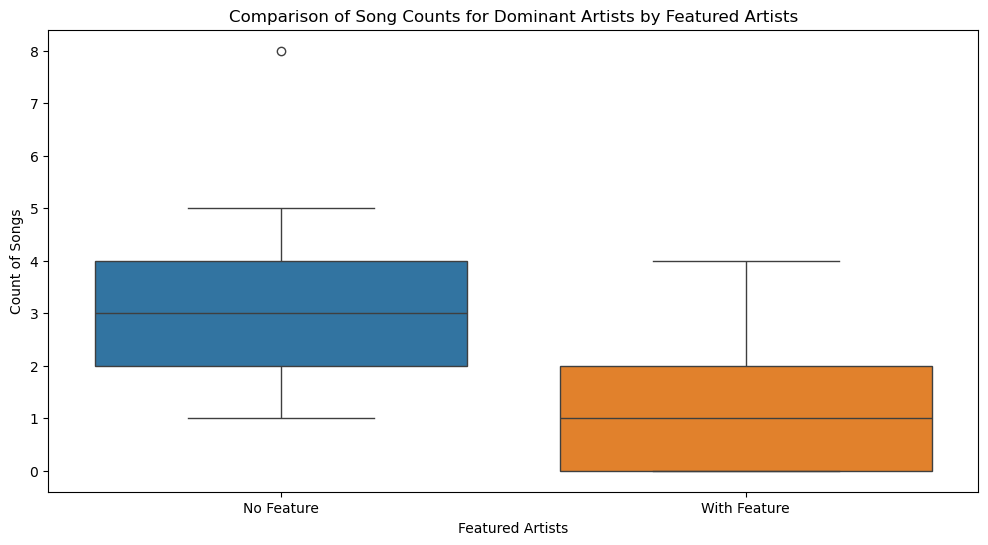

In [7]:
#plotting the plot for dominant artist song counts with and without featured artist
plt.figure(figsize=(12, 6))
sns.boxplot(data=dominant_artist_summary[['without_feature', 'with_feature']])
plt.title('Comparison of Song Counts for Dominant Artists by Featured Artists')
plt.xlabel('Featured Artists')
plt.ylabel('Count of Songs')
plt.xticks([0, 1], ['No Feature', 'With Feature'])
plt.show()

In [8]:
#Finding the dominant artist's highest ranked song and
#Comparing ranks to get songs with featured artists that have a higher rank than the former

highest_ranked_song = dominant_songs.loc[dominant_songs.groupby(['Year', 'Artist'])['Rank'].idxmin()]
merged_data = pd.merge(data_cleaned, highest_ranked_song[['Year', 'Artist', 'Rank']], on='Year', suffixes=('', '_dominant'))
featured_songs_above = merged_data[(merged_data['Featured Artists'] == 1) & (merged_data['Rank'] < merged_data['Rank_dominant'])]
featured_songs_count = featured_songs_above.groupby('Year').size().reset_index(name='count_above_dominant')
all_years = pd.DataFrame({'Year': data_cleaned['Year'].unique()})

#included this line because years where there existed no value, the year was skipped on the table
featured_songs_count = pd.merge(all_years, featured_songs_count, on='Year', how='left').fillna(0)

featured_songs_count = pd.merge(featured_songs_count, highest_ranked_song[['Year', 'Rank']], on='Year', how='left')
featured_songs_count.rename(columns={'Rank': 'highest_rank_dominant_artist'}, inplace=True)
songs_with_featured_artists = data_cleaned[data_cleaned['Featured Artists'] == 1]

featured_songs_count

,Year,count_above_dominant,highest_rank_dominant_artist
0,2003.0,0.0,1
1,2004.0,1.0,3
2,2005.0,2.0,8
3,2006.0,6.0,16
4,2007.0,8.0,22
5,2008.0,1.0,4
6,2009.0,1.0,8
7,2010.0,9.0,20
8,2011.0,5.0,12
9,2012.0,3.0,8


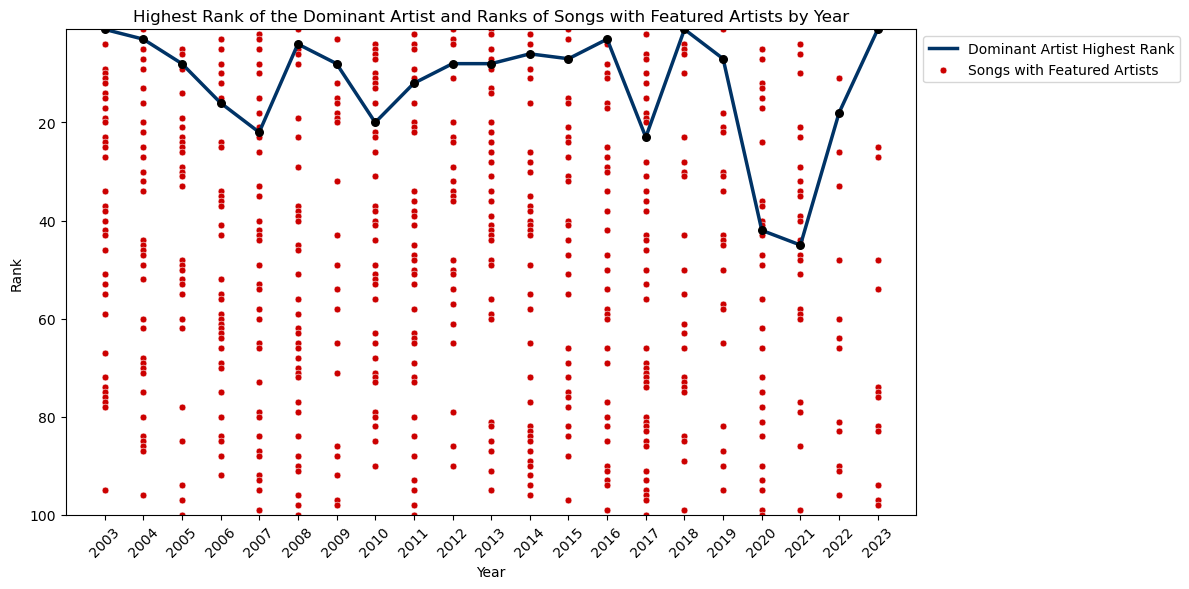

In [9]:
#creating line plot for the dominant artist's highest ranked song
#and scatter poltting all ranks of songs with featured artists
plt.figure(figsize=(12, 6))
# Line plot (line color deep blue, no markers)
sns.lineplot(
    x='Year', y='Rank', data=highest_ranked_song,
    color='#003366',       # line color
    label='Dominant Artist Highest Rank',
    linewidth=2.5,
    marker=None             # no markers on the line
)

# Overlay markers in black
plt.scatter(
    highest_ranked_song['Year'], highest_ranked_song['Rank'],
    color='black',          # marker color
    s=30,                   # marker size
    zorder=5                # ensure markers are on top
)

# Scatter plot for featured artists
sns.scatterplot(
    x='Year', y='Rank', data=songs_with_featured_artists,
    color='#CC0000',       # crimson red
    label='Songs with Featured Artists',
    s=24
)
plt.title('Highest Rank of the Dominant Artist and Ranks of Songs with Featured Artists by Year')
plt.xlabel('Year')
plt.ylabel('Rank')
plt.gca().invert_yaxis()
plt.ylim(100, 1)
plt.xticks(highest_ranked_song['Year'], rotation=45)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

In [15]:
X = data_cleaned[['Featured Artists']]
y_rank = data_cleaned['Rank']

X_train, X_test, y_rank_train, y_rank_test = train_test_split(X, y_rank, test_size=0.2, random_state=25)

linear_model = LinearRegression()
linear_model.fit(X_train, y_rank_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [16]:
y_rank_pred = linear_model.predict(X_test)
rank_mse = mean_squared_error(y_rank_test, y_rank_pred)
print('Rank Prediction Mean Squared Error:', rank_mse)

rank_no_feature = np.round(linear_model.predict([[0]])[0])
rank_with_feature = np.round(linear_model.predict([[1]])[0])
print('Predicted rank without feature:', rank_no_feature)
print('Predicted rank with feature:', rank_with_feature)

Rank Prediction Mean Squared Error: 871.9456335041283
Predicted rank without feature: 51.0
Predicted rank with feature: 49.0


/opt/conda/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [17]:
rank_data = {
    'Type': ['Without Feature', 'With Feature'],
    'Predicted Rank': [rank_no_feature, rank_with_feature]
}

rank_df = pd.DataFrame(rank_data)

<Figure size 1000x600 with 0 Axes>

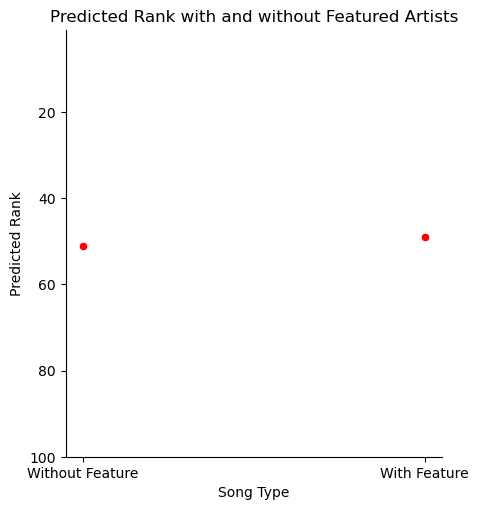

In [18]:
plt.figure(figsize=(10, 6))
sns.relplot(x='Type', y='Predicted Rank', data=rank_df, color='r')
plt.title('Predicted Rank with and without Featured Artists')
plt.xlabel('Song Type')
plt.ylabel('Predicted Rank')
plt.gca().invert_yaxis()
plt.ylim(100, 1)
plt.show()